In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [73]:
from sklearn import datasets
from sklearn import model_selection
from sklearn import preprocessing
from sklearn import linear_model
from sklearn import metrics

# Učitavanje skupa podataka

In [74]:
data = pd.read_csv('PRSA_data_2010.1.1-2014.12.31.csv')

In [75]:
data.head()

,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir
0,1,2010,1,1,0,NaN,-21,-11.0,1021.0,NW,1.79,0,0
1,2,2010,1,1,1,NaN,-21,-12.0,1020.0,NW,4.92,0,0
2,3,2010,1,1,2,NaN,-21,-11.0,1019.0,NW,6.71,0,0
3,4,2010,1,1,3,NaN,-21,-14.0,1019.0,NW,9.84,0,0
4,5,2010,1,1,4,NaN,-20,-12.0,1018.0,NW,12.97,0,0


# Pretprocesiranje podataka

In [76]:
data = data.drop(columns=['No'])
data = data.dropna(subset=['pm2.5'])

In [77]:
data.isnull().sum()

year     0
month    0
day      0
hour     0
pm2.5    0
DEWP     0
TEMP     0
PRES     0
cbwd     0
Iws      0
Is       0
Ir       0
dtype: int64

In [78]:
data = pd.get_dummies(data, columns=['cbwd'], dtype=int)

U okviru pripreme podataka uklanjaju se instance kod kojih nedostaje vrednost ciljne promenljive `pm2.5`, kao i atributi koji nisu potrebni za formiranje regresionog modela. Kategorički atribut `cbwd` transformiše se u numerički oblik kako bi mogao da se koristi kao ulaz regresionih modela.

In [79]:
data.head()

,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,Iws,Is,Ir,cbwd_NE,cbwd_NW,cbwd_SE,cbwd_cv
24,2010,1,2,0,129.0,-16,-4.0,1020.0,1.79,0,0,0,0,1,0
25,2010,1,2,1,148.0,-15,-4.0,1020.0,2.68,0,0,0,0,1,0
26,2010,1,2,2,159.0,-11,-5.0,1021.0,3.57,0,0,0,0,1,0
27,2010,1,2,3,181.0,-7,-5.0,1022.0,5.36,1,0,0,0,1,0
28,2010,1,2,4,138.0,-7,-5.0,1022.0,6.25,2,0,0,0,1,0


In [80]:
data.shape

(41757, 15)

In [81]:
data.info()

<class 'pandas.DataFrame'>
Index: 41757 entries, 24 to 43823
Data columns (total 15 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   year     41757 non-null  int64  
 1   month    41757 non-null  int64  
 2   day      41757 non-null  int64  
 3   hour     41757 non-null  int64  
 4   pm2.5    41757 non-null  float64
 5   DEWP     41757 non-null  int64  
 6   TEMP     41757 non-null  float64
 7   PRES     41757 non-null  float64
 8   Iws      41757 non-null  float64
 9   Is       41757 non-null  int64  
 10  Ir       41757 non-null  int64  
 11  cbwd_NE  41757 non-null  int64  
 12  cbwd_NW  41757 non-null  int64  
 13  cbwd_SE  41757 non-null  int64  
 14  cbwd_cv  41757 non-null  int64  
dtypes: float64(4), int64(11)
memory usage: 5.1 MB


Ulazni atributi izdvajaju se u skup `x`, dok ciljnu promenljivu `pm2.5` predstavlja skup `y`.

In [82]:
x = data.drop(columns=['pm2.5'])
y = data['pm2.5']

In [83]:
x.shape

(41757, 14)

In [84]:
y.shape

(41757,)

# Podela podataka

U ovom koraku vršimo podelu skupa podataka na trening, validacioni i test skup. Trening skup koristi se za učenje modela, validacioni skup za podešavanje hiperparametara i izbor najboljeg modela, dok se test skup koristi za konačnu evaluaciju performansi modela.

In [85]:
x_train_val, x_test, y_train_val, y_test = model_selection.train_test_split(x, y, test_size=0.33, random_state=7)

In [86]:
x_train, x_val, y_train, y_val = model_selection.train_test_split(x_train_val, y_train_val, train_size=0.8, random_state=7)

# Standardizacija

U ovom koraku vršimo standardizaciju podataka koristeći parametre izračunate na trening skupu. Na taj način izbegava se curenje informacija iz validacionog i test skupa u proces treniranja modela.

In [87]:
scaler = preprocessing.StandardScaler()

In [88]:
scaler.fit(x_train)

StandardScaler()

In [89]:
x_train = scaler.transform(x_train)
x_val = scaler.transform(x_val)
x_test = scaler.transform(x_test)

# Linearna regresija bez regularizacije

In [90]:
base_model = linear_model.LinearRegression()

In [91]:
base_model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](14,)","[ 0.87,-3.6 , 6.54,...,-7.29, 5.27, 4.86]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,98.83
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,14
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(13)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](14,)","[263.7 ,186.39,179.64,..., 64.44, 53.93, 0. ]"


In [92]:
y_train_pred = base_model.predict(x_train)
y_val_pred = base_model.predict(x_val)
y_test_pred = base_model.predict(x_test)

## Evaluacija modela linearne regresije bez regularizacije

Performanse modela procenjuju se na validacionom skupu korišćenjem R², MAE i RMSE metrika. R² pokazuje koliki deo varijabilnosti ciljne promenljive model uspeva da objasni, dok MAE i RMSE predstavljaju mere greške predikcije.

In [93]:
print('Train')
print('R2:', metrics.r2_score(y_train, y_train_pred))
print('MAE:', metrics.mean_absolute_error(y_train, y_train_pred))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_train, y_train_pred)))

print('\nValidation')
print('R2:', metrics.r2_score(y_val, y_val_pred))
print('MAE:', metrics.mean_absolute_error(y_val, y_val_pred))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_val, y_val_pred)))

print('\nTest')
print('R2:', metrics.r2_score(y_test, y_test_pred))
print('MAE:', metrics.mean_absolute_error(y_test, y_test_pred))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, y_test_pred)))

Train
R2: 0.2796386427278953
MAE: 56.75845411475262
RMSE: 77.97225797544415

Validation
R2: 0.2735171643694503
MAE: 55.45700671129612
RMSE: 76.18916826739125

Test
R2: 0.26815196521767337
MAE: 57.603333416856394
RMSE: 79.89597212472071


Dobijeni rezultati pokazuju da osnovni model linearne regresije ima ograničenu sposobnost predviđanja koncentracije PM2.5. Dobijena R² vrednost ukazuje da linearni model objašnjava samo deo varijabilnosti ciljne promenljive, dok vrednosti MAE i RMSE ukazuju na prisustvo značajnih grešaka u pojedinim predikcijama.

Ovakav rezultat je u skladu sa početnom analizom podataka, gde nije uočena jaka linearna povezanost pojedinačnih meteoroloških atributa sa ciljnom promenljivom.

# Linearna regresija sa ElasticNet regularizacijom

U cilju ispitivanja uticaja regularizacije primenjuje se ElasticNet regresija, koja kombinuje L1 i L2 regularizaciju. Hiperparametri `alpha` i `l1_ratio` podešavaju se na osnovu rezultata dobijenih na validacionom skupu.

U ovom koraku trenira se više ElasticNet modela sa različitim vrednostima hiperparametara `alpha` i `l1_ratio`. Najbolja kombinacija hiperparametara bira se na osnovu R² vrednosti ostvarene na validacionom skupu.

In [94]:
alphas = [0.001, 0.01, 0.1, 0.5, 1]
l1_ratios = [0.1, 0.5, 0.9]

best_score = -np.inf
best_alpha = None
best_l1_ratio = None
best_model = None

for alpha in alphas:
    for l1_ratio in l1_ratios:
       
        model = linear_model.ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=10000)
        model.fit(x_train, y_train)
        y_val_pred = model.predict(x_val)
        score = metrics.r2_score(y_val, y_val_pred)
       
        if score > best_score:
            best_score = score
            best_alpha = alpha
            best_l1_ratio = l1_ratio
            best_model = model

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.723484e+04, tolerance: 1.889e+04
  model = cd_fast.enet_coordinate_descent(


In [95]:
print('Najbolji alpha:', best_alpha)
print('Najbolji l1_ratio:', best_l1_ratio)
print('Validation R2:', best_score)

Najbolji alpha: 0.01
Najbolji l1_ratio: 0.5
Validation R2: 0.27374229093632074


Na osnovu rezultata na validacionom skupu izabrana je kombinacija hiperparametara koja ostvaruje najveću R² vrednost. Sa izabranim parametrima formira se konačni ElasticNet model.

In [96]:
elastic_model = best_model

y_test_pred_elastic = elastic_model.predict(x_test)

print('ElasticNet Test')
print('R2:', metrics.r2_score(y_test, y_test_pred_elastic))
print('MAE:', metrics.mean_absolute_error(y_test, y_test_pred_elastic))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, y_test_pred_elastic)))

ElasticNet Test
R2: 0.2680592933316156
MAE: 57.50739925362372
RMSE: 79.90103046723014


ElasticNet model sa parametrima `alpha = 0.01` i `l1_ratio = 0.5` ostvaruje na test skupu R² vrednost od približno 0,268, MAE od 57,51 i RMSE od 79,90.

Rezultati su gotovo identični rezultatima linearne regresije bez regularizacije. ElasticNet ostvaruje neznatno niži R², nešto nižu MAE vrednost i praktično istu RMSE vrednost. Može se zaključiti da primena ElasticNet regularizacije u ovom slučaju nije dovela do značajnog poboljšanja performansi modela.

Oba linearna modela objašnjavaju približno 27% varijabilnosti ciljne promenljive, što ukazuje da linearni pristup ima ograničenu sposobnost modelovanja koncentracije PM2.5. Ovo sugeriše da između ulaznih atributa i ciljne promenljive verovatno postoje složeniji i nelinearni odnosi, koji mogu biti bolje obuhvaćeni drugim regresionim modelima.

In [97]:
feature_names = x.columns
number_of_features = len(feature_names)

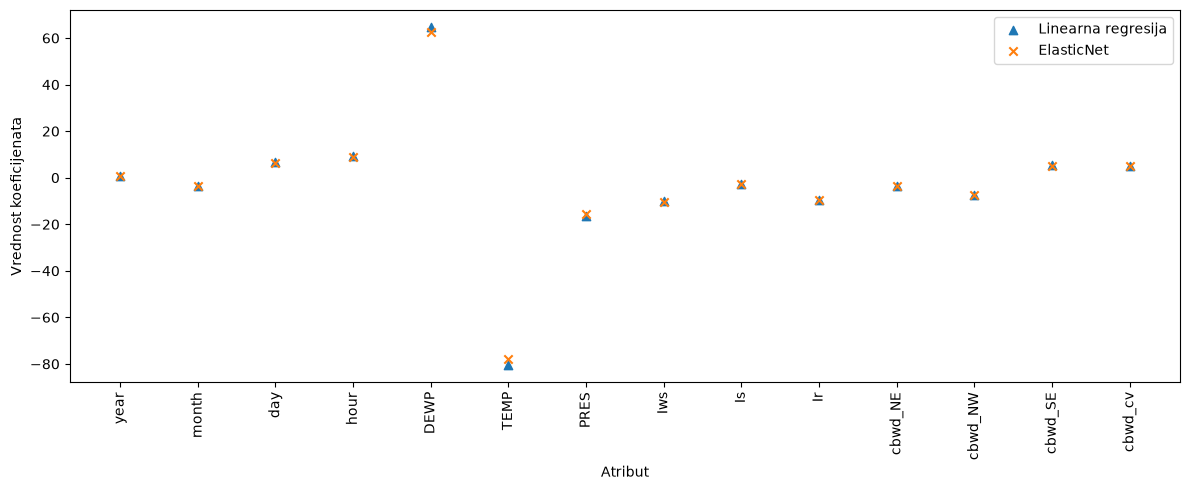

In [98]:
plt.figure(figsize=(12, 5))

plt.scatter(range(number_of_features), base_model.coef_.ravel(), marker='^', label='Linearna regresija')
plt.scatter(range(number_of_features), elastic_model.coef_.ravel(), marker='x', label='ElasticNet')
plt.xticks(range(number_of_features), feature_names, rotation=90)
plt.xlabel('Atribut')
plt.ylabel('Vrednost koeficijenata')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

Poređenjem koeficijenata osnovne linearne regresije i ElasticNet modela može se uočiti da regularizacija nije dovela do velikih promena njihovih vrednosti. Ovo je u skladu sa veoma sličnim rezultatima oba modela na test skupu, pa se može zaključiti da ElasticNet regularizacija u ovom slučaju nema značajan uticaj na performanse modela.

# Linearna regresija sa ElasticNet regularizacijom na uniji trening i validacionog skupa

In [99]:
x_train_val_scaled = np.vstack([x_train, x_val])
y_train_val        = pd.concat([y_train, y_val])

In [100]:
x_train_val_scaled.shape

(27977, 14)

In [101]:
y_train_val.shape

(27977,)

In [102]:
elastic_model_train_val = linear_model.ElasticNet(alpha=best_alpha, l1_ratio=best_l1_ratio, max_iter=10000)
elastic_model_train_val.fit(x_train_val_scaled, y_train_val)

,"alpha alpha: float, default=1.0Constant that multiplies the penalty terms. Defaults to 1.0.See the notes for the exact mathematical meaning of thisparameter. ``alpha = 0`` is equivalent to an ordinary least square,solved by the :class:`LinearRegression` object. For numericalreasons, using ``alpha = 0`` with the ``Lasso`` object is not advised.Given this, you should use the :class:`LinearRegression` object.",0.01
,"max_iter max_iter: int, default=1000The maximum number of iterations.",10000
,"l1_ratio l1_ratio: float, default=0.5The ElasticNet mixing parameter, with ``0 <= l1_ratio <= 1``. For``l1_ratio = 0`` the penalty is an L2 penalty. ``For l1_ratio = 1`` itis an L1 penalty. For ``0 < l1_ratio < 1``, the penalty is acombination of L1 and L2.",0.5
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If ``False``, thedata is assumed to be already centered.",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.Check :ref:`an example on how to use a precomputed Gram Matrix in ElasticNet<sphx_glr_auto_examples_linear_model_plot_elastic_net_precomputed_gram_matrix_with_weighted_samples.py>`for details.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [103]:
y_test_pred_elastic_train_val = elastic_model_train_val.predict(x_test)

print('ElasticNet Test - Unija Trening i Validacija')
print('R2:', metrics.r2_score(y_test, y_test_pred_elastic_train_val))
print('MAE:', metrics.mean_absolute_error(y_test, y_test_pred_elastic_train_val))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, y_test_pred_elastic_train_val)))

ElasticNet Test - Unija Trening i Validacija
R2: 0.2681971357902826
MAE: 57.410101009559455
RMSE: 79.89350644719791


Model treniran na spojenom skupu postiže praktično nepromenjen R², nešto nižu MAE vrednost i skoro identičnu RMSE vrednost. Odavde sledi da objedinjavanje trening i validacionog skupa nije značajnije uticalo na performanse, čime se potvrđuje stabilnost modela.

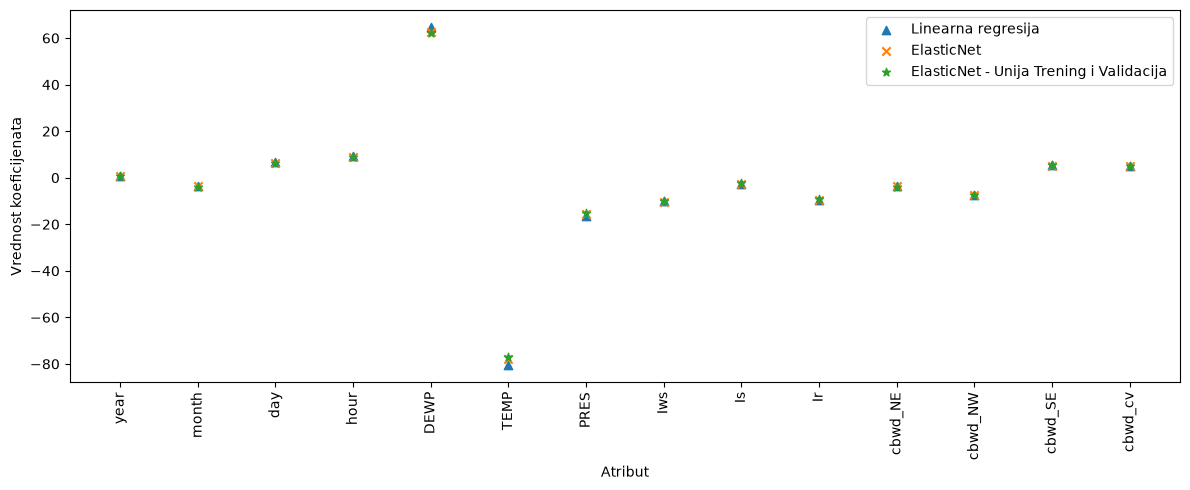

In [104]:
plt.figure(figsize=(12, 5))

plt.scatter(range(number_of_features), base_model.coef_.ravel(), marker='^', label='Linearna regresija')
plt.scatter(range(number_of_features), elastic_model.coef_.ravel(), marker='x', label='ElasticNet')
plt.scatter(range(number_of_features), elastic_model_train_val.coef_.ravel(), marker='*', label='ElasticNet - Unija Trening i Validacija')
plt.xticks(range(number_of_features), feature_names, rotation=90)
plt.xlabel('Atribut')
plt.ylabel('Vrednost koeficijenata')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

Poređenjem koeficijenata linearne regresije, ElasticNet modela i ElasticNet modela treniranog na objedinjenom trening i validacionom skupu može se uočiti da se njihove vrednosti za sve atribute gotovo u potpunosti poklapaju. Ovo je u skladu sa gotovo identičnim rezultatima svih modela na test skupu, pa se može zaključiti da ni regularizacija ni uključivanje validacionog skupa u trening nemaju značajan uticaj na strukturu koju model uči, niti na njegove performanse.

# Čuvanje modela i scaler-a

In [105]:
import joblib

In [108]:
joblib.dump(base_model, "../models/02_LinearRegression.pkl")
joblib.dump(elastic_model, "../models/02_ElasticNet.pkl")
joblib.dump(elastic_model_train_val, "../models/02_ElasticNetTrainVal.pkl")
joblib.dump(scaler, "../models/02_scaler.pkl")

['../models/02_scaler.pkl']